In [8]:
#instalare dependinte
!pip install copernicusmarine xarray netCDF4 dask

In [8]:
#instalare dependinte
!pip install copernicusmarine xarray netCDF4 dask

In [12]:
import os
import copernicusmarine

# 1. Creăm folderul unde se vor salva datele
os.makedirs("data/input", exist_ok=True)

# 2. Definim ID-ul produsului pentru Marea Neagră
dataset_id = "cmems_obs-oc_blk_bgc-reflectance_nrt_l3-multi-1km_P1D"

# 3. Descărcăm doar datele pentru 12 August 2026
print("Încep descărcarea datelor pentru 12 August 2026...")
copernicusmarine.subset(
    dataset_id=dataset_id,
    output_directory="data/input",
    start_datetime="2026-08-12T00:00:00",
    end_datetime="2026-08-12T23:59:59",
    force_download=True  # Am revenit la varianta standard acceptată de majoritatea versiunilor
)
print("Descărcare finalizată!")

WARNING - 2026-08-13T14:32:16Z - 'force_download' has been deprecated.


Încep descărcarea datelor pentru 12 August 2026...


INFO - 2026-08-13T14:32:16Z - Selected dataset version: "202207"
INFO - 2026-08-13T14:32:16Z - Selected dataset part: "default"
WARNING - 2026-08-13T14:32:20Z - Some of your subset selection [2026-08-12 00:00:00+00:00, 2026-08-12 23:59:59+00:00] for the time dimension exceed the dataset coordinates [2026-08-03 00:00:00+00:00, 2026-08-12 00:00:00+00:00]
INFO - 2026-08-13T14:32:22Z - Starting download. Please wait...


  0%|          | 0/52 [00:00<?, ?it/s]

INFO - 2026-08-13T14:32:24Z - Successfully downloaded to data/input/cmems_obs-oc_blk_bgc-reflectance_nrt_l3-multi-1km_P1D_multi-vars_26.51E-41.99E_40.01N-47.99N_2026-08-12.nc


Descărcare finalizată!


In [16]:
import xarray as xr

# Citim fișierul/fișierele descărcate
ds = xr.open_mfdataset("data/input/*.nc")

# Afișăm structura
ds

<xarray.Dataset> Size: 49MB
Dimensions:     (time: 1, latitude: 790, longitude: 1101)
Coordinates:
  * latitude    (latitude) float32 3kB 40.01 40.02 40.03 ... 47.97 47.98 47.99
  * longitude   (longitude) float32 4kB 26.51 26.52 26.54 ... 41.96 41.98 41.99
  * time        (time) datetime64[ns] 8B 2026-08-12
Data variables: (12/13)
    QI_RRS412   (time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 790, 1101), meta=np.ndarray>
    QI_RRS443   (time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 790, 1101), meta=np.ndarray>
    QI_RRS490   (time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 790, 1101), meta=np.ndarray>
    QI_RRS510   (time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 790, 1101), meta=np.ndarray>
    QI_RRS555   (time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 790, 1101), meta=np.ndarray>
    QI_RRS670   (time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 790, 1101), meta=np.ndarray>
    ...          ...
    RRS443      (time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 790, 1101), meta=np.ndarray>
    RRS490      (time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 790, 1101), meta=np.ndarray>
    RRS510      (time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 790, 1101), meta=np.ndarray>
    RRS555      (time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 790, 1101), meta=np.ndarray>
    RRS670      (time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 790, 1101), meta=np.ndarray>
    SENSORMASK  (time, latitude, longitude) float64 7MB dask.array<chunksize=(1, 790, 1101), meta=np.ndarray>
Attributes:
    references:                
    source:                    surface observation
    history:                    
    comment:                   
    Conventions:               CF-1.4
    title:                     cmems_obs-oc_blk_bgc-reflectance_nrt_l3-multi-...
    institution:               CNR-GOS
    contact:                   technical@gos.artov.isac.cnr.it
    copernicusmarine_version:  2.1.3

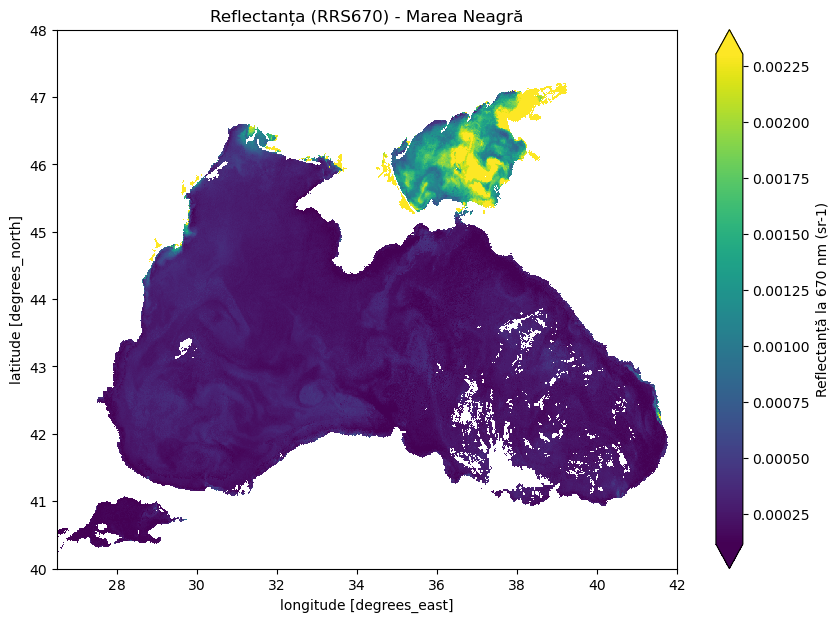

In [14]:
import matplotlib.pyplot as plt

# Deoarece datele au fost descărcate pentru o zi specifică, structura are probabil 
# o dimensiune de timp (time=1). Folosim .squeeze() pentru a o transforma 
# într-o simplă hartă 2D (latitudine x longitudine).
harta_2d = ds['RRS670'].squeeze()

# Setăm dimensiunea imaginii pentru a o vedea mai bine
plt.figure(figsize=(10, 7))

# Generăm graficul
harta_2d.plot(
    cmap='viridis',       # O paletă de culori excelentă pentru date științifice
    robust=True,          # Elimină valorile extreme (outliers) pentru a spori contrastul culorilor
    cbar_kwargs={'label': 'Reflectanță la 670 nm (sr-1)'} # Eticheta barei de culori
)

# Adăugăm un titlu reprezentativ
plt.title('Reflectanța (RRS670) - Marea Neagră')

# Afișăm rezultatul
plt.show()

In [17]:
import numpy as np

# Extragem benzile de reflectanță (Rrs). 
# Adaptăm numele exact pe care le-ai văzut în structura ds (ex: RRS443, RRS490, RRS560, RRS670).
rrs_443 = ds['RRS443']
rrs_490 = ds['RRS490']
rrs_560 = ds['RRS555']
rrs_670 = ds['RRS670']

# Creăm o mască pentru apă validă (eliminăm norii și uscatul)
# Presupunem că dacă reflectanța în banda de rosu este NaN, pixelul este acoperit de nori sau este uscat
valid_water_mask = rrs_560.notnull()

# Aplicăm masca pe tot dataset-ul pentru a curăța datele
ds_clean = ds.where(valid_water_mask)

print("Datele au fost curățate de nori și valori invalide!")

Datele au fost curățate de nori și valori invalide!


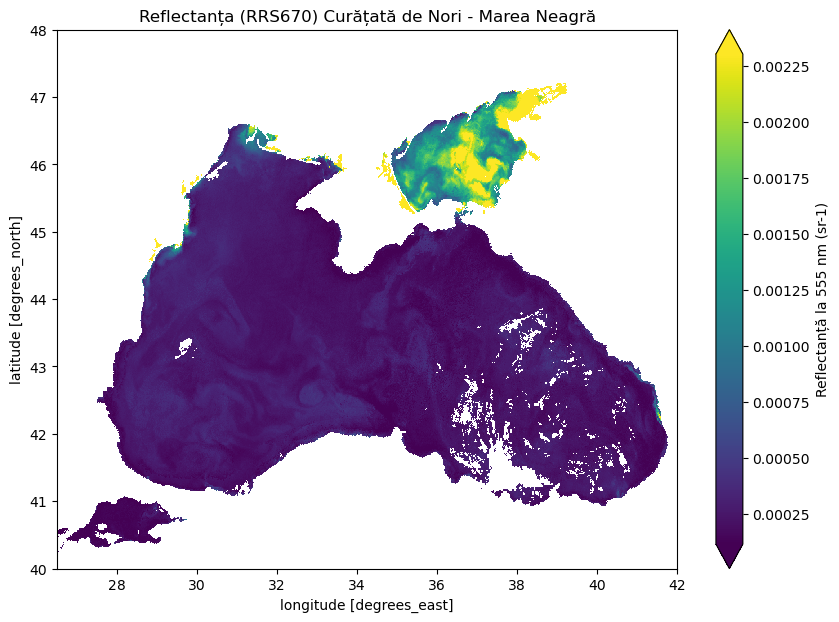

In [19]:
import matplotlib.pyplot as plt

# Selectăm variabila din dataset-ul curățat (ds_clean) 
# și folosim squeeze() pentru a extrage harta 2D (fără dimensiunea de timp)
harta_curatata = ds_clean['RRS670'].squeeze()

# Setăm dimensiunea imaginii
plt.figure(figsize=(10, 7))

# Generăm graficul
harta_curatata.plot(
    cmap='viridis',
    robust=True,          # Optimizează contrastul vizual
    cbar_kwargs={'label': 'Reflectanță la 555 nm (sr-1)'}
)

# Adăugăm un titlu
plt.title('Reflectanța (RRS670) Curățată de Nori - Marea Neagră')

# Afișăm rezultatul
plt.show()

In [20]:
import numpy as np
import xarray as xr

# ==========================================
# 1. CONSTANTE FIZICE (Pope & Fry 1997, Morel 1974)
# ==========================================
Ct = 0.013      # Pragul de contrast al ochiului uman
rho = 0.15      # Reflectanța discului Secchi

g0, g1 = 0.089, 0.125 # Constante Gordon

# Definim proprietățile apei pure pentru benzile pe care le evaluăm (443, 490, 555 nm)
bands = [443, 490, 555]
aw_dict  = {443: 0.007,  490: 0.015,  555: 0.0596}
bbw_dict = {443: 0.0022, 490: 0.0015, 555: 0.00093}
bw_dict  = {443: 0.0044, 490: 0.003,  555: 0.00186}

# ==========================================
# 2. TRANSFORMAREA Rrs -> rrs (sub suprafață)
# ==========================================
rrs = ds_clean / (0.52 + 1.7 * ds_clean)

# ==========================================
# 3. ALGORITMUL QAA v6 - DERIVAREA PARAMETRILOR DE BAZĂ
# ==========================================
u_555 = (-g0 + np.sqrt(g0**2 + 4 * g1 * rrs['RRS555'])) / (2 * g1)
chi = np.log10((rrs['RRS443'] + rrs['RRS490']) / (rrs['RRS555'] + 5 * (rrs['RRS670'] / rrs['RRS490']) * rrs['RRS670']))

# Absorbția și retroîmprăștierea la 555 nm
a_555 = aw_dict[555] + 10**(-1.146 - 1.366 * chi - 0.469 * chi**2)
bb_555 = (u_555 * a_555) / (1 - u_555)
bbp_555 = bb_555 - bbw_dict[555]

# Exponentul spectral (eta)
eta = 2.0 * (1 - 1.2 * np.exp(-0.9 * (rrs['RRS443'] / rrs['RRS555'])))

# ==========================================
# 4. CALCULUL PENTRU FIECARE BANDĂ VIZIBILĂ
# ==========================================
Kd_dict = {}
Zsd_dict = {}

for wl in bands:
    # 1. Extrapolăm b_b (retroîmprăștierea) pentru banda curentă
    bbp = bbp_555 * (555 / wl)**eta
    bb = bbp + bbw_dict[wl]

    # 2. Obținem 'u' și calculăm absorbția 'a'
    u = (-g0 + np.sqrt(g0**2 + 4 * g1 * rrs[f'RRS{wl}'])) / (2 * g1)
    a = ((1 - u) / u) * bb

    # 3. Calculăm Kd conform Lee et al. (2013)
    Kd = 1.05 * a + 4.18 * (1 - 0.52 * np.exp(-10.8 * a)) * bb
    Kd_dict[wl] = Kd

    # 4. Calculăm c (atenuarea fasciculului), presupunând un raport bbp/bp tipic
    b = (bbp / 0.015) + bw_dict[wl]
    c = a + b

    # 5. Calculăm Zsd specific acestei benzi
    Rrs_above = ds_clean[f'RRS{wl}']
    Zsd = (1 / (Kd + c)) * np.log((rho - Rrs_above) / Ct)
    Zsd_dict[wl] = Zsd

# ==========================================
# 5. GĂSIREA FEREASTREI DE TRANSPARENȚĂ ȘI APLICAREA ZSD
# ==========================================
# Concatenăm matricile Kd pentru a găsi minimul pentru FIECARE pixel
Kd_stack = xr.concat([Kd_dict[443], Kd_dict[490], Kd_dict[555]], dim='band')
Kd_min = Kd_stack.min(dim='band')

# Folosim funcția logică xarray.where pentru a alege Zsd-ul corespunzător lui Kd_min
# Traducere: Dacă minimul e la 443, alege Zsd_443; altfel, dacă e la 490, alege Zsd_490; altfel, 555.
Zsd_final = xr.where(Kd_dict[443] == Kd_min, Zsd_dict[443],
            xr.where(Kd_dict[490] == Kd_min, Zsd_dict[490], 
                     Zsd_dict[555]))

Zsd_final.name = "Secchi_Depth_m"
ds_clean['ZSD'] = Zsd_final

# Salvăm în netCDF
import os
os.makedirs("data/output", exist_ok=True)
ds_clean['ZSD'].to_netcdf("data/output/zsd_black_sea_today.nc")

print("Zsd calculat folosind fereastra de transparență variabilă! Fișierul a fost salvat.")

Zsd calculat folosind fereastra de transparență variabilă! Fișierul a fost salvat.


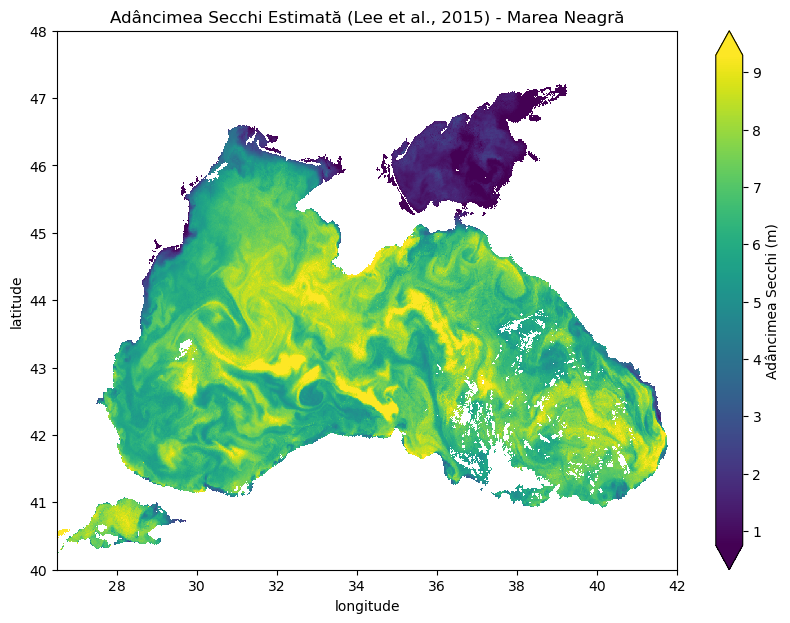

In [21]:
import matplotlib.pyplot as plt

# Extragem variabila ZSD (Secchi Depth) din dataset-ul nostru
# Folosim squeeze() pentru a elimina dimensiunea de timp și a obține o hartă 2D
harta_secchi = ds_clean['ZSD'].squeeze()

# Setăm dimensiunea imaginii
plt.figure(figsize=(10, 7))

# Generăm graficul
# 'viridis' este o paletă bună, dar pentru adâncime/claritate 'GnBu_r' sau 'viridis' sunt excelente
harta_secchi.plot(
    cmap='viridis',
    robust=True,  # Taie extremele (outliers) pentru a vedea mai bine variațiile de pe hartă
    cbar_kwargs={'label': 'Adâncimea Secchi (m)'}
)

# Adăugăm un titlu reprezentativ
plt.title('Adâncimea Secchi Estimată (Lee et al., 2015) - Marea Neagră')

# Afișăm graficul
plt.show()